# Problem 2.a: Feature Extraction (30 points)

Use pretrained ResNet as feature extractor + Train traditional ML classifier

**Dataset:** UCMerced - 21 classes, download from http://weegee.vision.ucmerced.edu/datasets/landuse.html

**Steps:**
1. Load ResNet, remove FC layer
2. Extract features for all images
3. Train XGBoost/SVM
4. Report: Accuracy, Precision, Recall, F1, Confusion Matrices





## 1. Install Required Packages

First, let's install all the packages we'll need for this problem.


In [1]:
%pip install torch torchvision numpy pandas scikit-learn xgboost matplotlib seaborn Pillow tqdm --quiet


## 2. Import Libraries and Setup

Import all necessary libraries and set up our environment with reproducible random seeds.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from xgboost import XGBClassifier

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


## 3. Set Data Path

**IMPORTANT - READ BEFORE RUNNING:**

### For Google Colab (RECOMMENDED):
1. **Uncomment** lines 1-3 (the Colab section)
2. **Comment out** line 6 (the local path)
3. Make sure your dataset is uploaded to the specified Drive path

### For Local Execution:
1. Keep line 6 as is (local path)
2. Lines 1-3 should remain commented out


In [4]:
# For Google Colab (uncomment these lines if using Colab):
from google.colab import drive
drive.mount('/content/drive')
DATA_ROOT = '/content/drive/MyDrive/IMGS589/HW5/UCMerced_LandUse/Images'

# # For Local (use this for now):
# DATA_ROOT = '/Users/varagantibasanthkumar/Desktop/ IMGS 589/-Applications-of-Machine-learning-in-Remote-Sensing/HW5/dl/UCMerced_LandUse/Images'

# Verify path exists
if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(f"Data directory not found: {DATA_ROOT}")

print(f"Data directory: {DATA_ROOT}")
print(f"Classes found: {len(os.listdir(DATA_ROOT))}")


Mounted at /content/drive
Data directory: /content/drive/MyDrive/IMGS589/HW5/UCMerced_LandUse/Images
Classes found: 21


## 4. Load and Explore Dataset

Load all image paths and labels, then perform exploratory data analysis.


In [5]:
def load_dataset_paths(root_dir):
    """
    Load all image paths and their corresponding labels.

    Args:
        root_dir: Root directory containing class subdirectories

    Returns:
        image_paths: List of full paths to images
        labels: List of class labels
        class_names: List of unique class names
    """
    image_paths = []
    labels = []
    class_names = sorted(os.listdir(root_dir))

    # Remove any hidden files
    class_names = [c for c in class_names if not c.startswith('.')]

    for class_name in class_names:
        class_dir = os.path.join(root_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        for img_name in os.listdir(class_dir):
            if img_name.endswith(('.tif', '.jpg', '.png')):
                image_paths.append(os.path.join(class_dir, img_name))
                labels.append(class_name)

    return image_paths, labels, class_names

# Load dataset
image_paths, labels, class_names = load_dataset_paths(DATA_ROOT)

print(f"Total images: {len(image_paths)}")
print(f"Total classes: {len(class_names)}")
print(f"\nClass names:")
for i, cls in enumerate(class_names, 1):
    count = labels.count(cls)
    print(f"  {i:2d}. {cls:20s} - {count} images")


Total images: 2100
Total classes: 21

Class names:
   1. agricultural         - 100 images
   2. airplane             - 100 images
   3. baseballdiamond      - 100 images
   4. beach                - 100 images
   5. buildings            - 100 images
   6. chaparral            - 100 images
   7. denseresidential     - 100 images
   8. forest               - 100 images
   9. freeway              - 100 images
  10. golfcourse           - 100 images
  11. harbor               - 100 images
  12. intersection         - 100 images
  13. mediumresidential    - 100 images
  14. mobilehomepark       - 100 images
  15. overpass             - 100 images
  16. parkinglot           - 100 images
  17. river                - 100 images
  18. runway               - 100 images
  19. sparseresidential    - 100 images
  20. storagetanks         - 100 images
  21. tenniscourt          - 100 images


### 4.1 Visualize Sample Images

Let's visualize a few sample images from different classes to understand our dataset better.


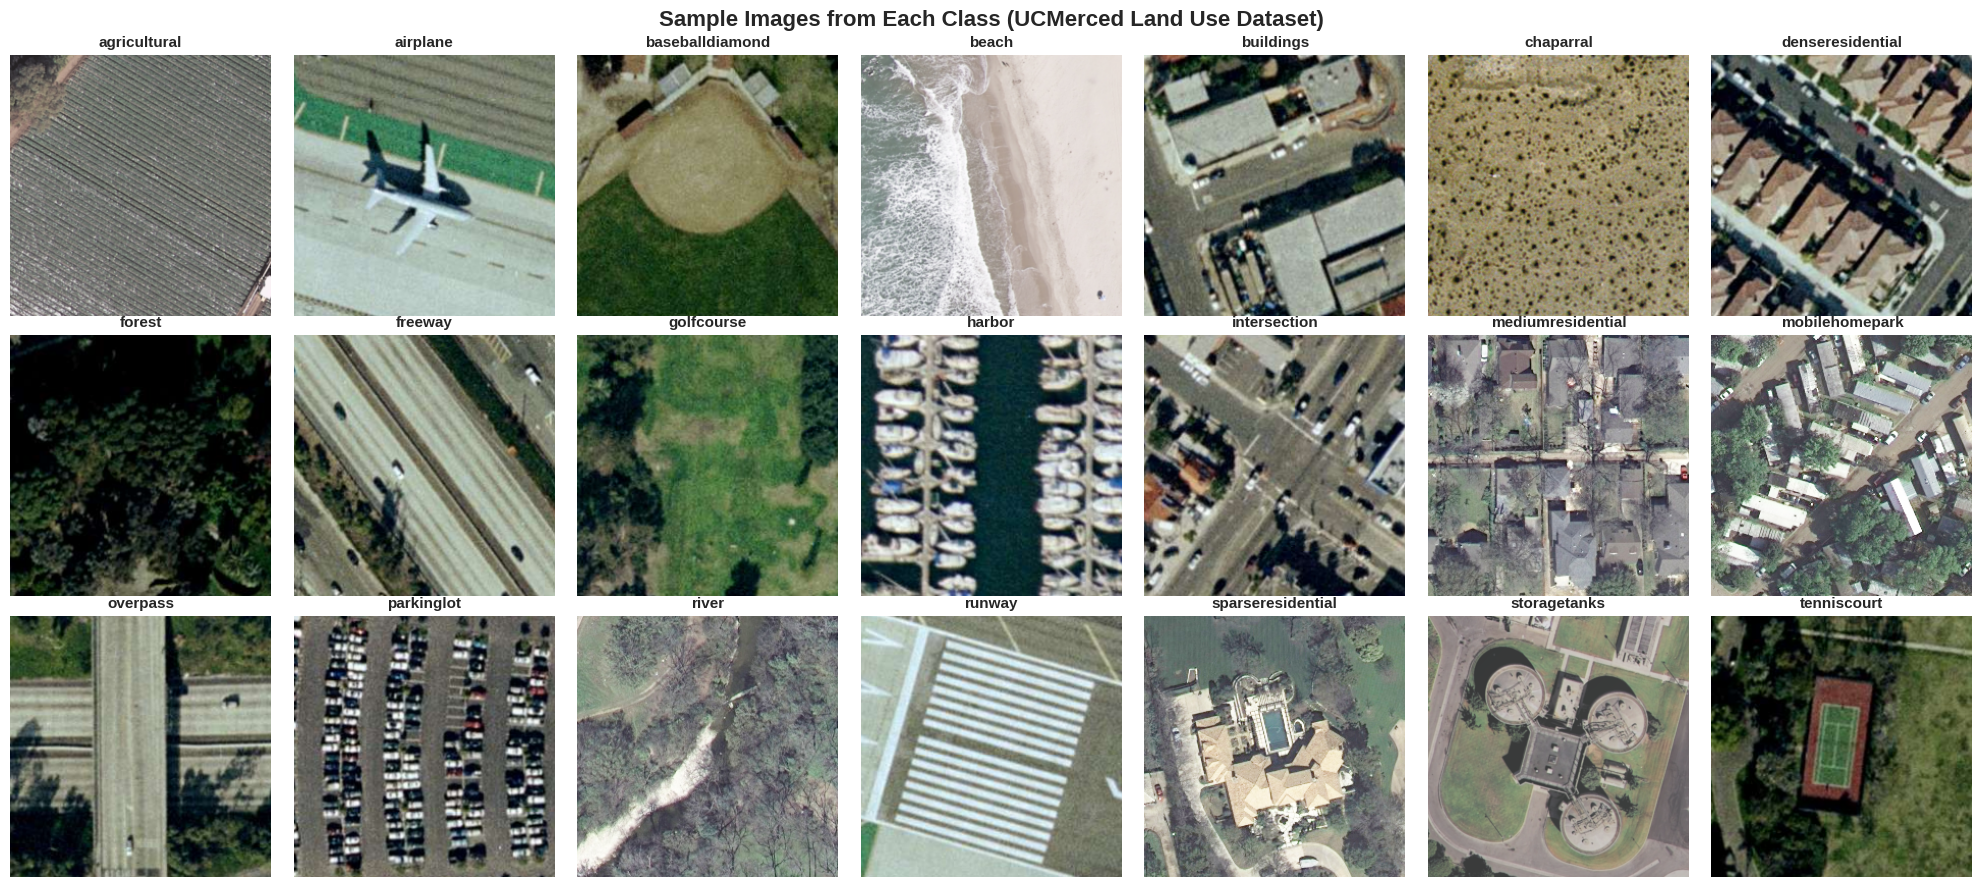

In [6]:
# Visualize sample images from each class
fig, axes = plt.subplots(3, 7, figsize=(20, 9))
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    # Get first image from this class
    class_images = [p for p, l in zip(image_paths, labels) if l == class_name]
    img_path = class_images[0]

    img = Image.open(img_path).convert('RGB')
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Images from Each Class (UCMerced Land Use Dataset)',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


## 5. Data Splitting

Split the dataset into train (70%), validation (15%), and test (15%) sets with stratification to maintain class balance.


In [7]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

# First split: 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels_encoded,
    test_size=0.30,
    random_state=SEED,
    stratify=labels_encoded
)

# Second split: Split temp into 50-50 for val and test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f"Dataset splits:")
print(f"  Train:      {len(X_train):4d} images ({len(X_train)/len(image_paths)*100:.1f}%)")
print(f"  Validation: {len(X_val):4d} images ({len(X_val)/len(image_paths)*100:.1f}%)")
print(f"  Test:       {len(X_test):4d} images ({len(X_test)/len(image_paths)*100:.1f}%)")
print(f"  Total:      {len(image_paths):4d} images")

# Verify class distribution
print(f"\nClass distribution in each split:")
print(f"  Train:      {np.bincount(y_train)}")
print(f"  Validation: {np.bincount(y_val)}")
print(f"  Test:       {np.bincount(y_test)}")


Dataset splits:
  Train:      1470 images (70.0%)
  Validation:  315 images (15.0%)
  Test:        315 images (15.0%)
  Total:      2100 images

Class distribution in each split:
  Train:      [70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70 70]
  Validation: [15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15]
  Test:       [15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15 15]


## 6. Define Image Transforms

Define transforms with ImageNet normalization (required for pretrained models).


In [8]:
# ImageNet normalization values (REQUIRED for pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet expects 224x224 input
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print(f"Transform pipeline created:")
print(f"  - Resize to 224x224")
print(f"  - Convert to tensor")
print(f"  - Normalize with ImageNet mean={IMAGENET_MEAN}")
print(f"                          std={IMAGENET_STD}")


Transform pipeline created:
  - Resize to 224x224
  - Convert to tensor
  - Normalize with ImageNet mean=[0.485, 0.456, 0.406]
                          std=[0.229, 0.224, 0.225]


## 7. Create Custom Dataset Class

Create a PyTorch Dataset class for loading images.


In [9]:
class UCMercedDataset(Dataset):
    """Custom Dataset for UCMerced Land Use images."""

    def __init__(self, image_paths, labels, transform=None):
        """
        Args:
            image_paths: List of paths to images
            labels: List of encoded labels
            transform: Optional transform to be applied
        """
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label

# Create dataset instances
train_dataset = UCMercedDataset(X_train, y_train, transform=transform)
val_dataset = UCMercedDataset(X_val, y_val, transform=transform)
test_dataset = UCMercedDataset(X_test, y_test, transform=transform)

print(f"Datasets created:")
print(f"  Train dataset: {len(train_dataset)} samples")
print(f"  Val dataset:   {len(val_dataset)} samples")
print(f"  Test dataset:  {len(test_dataset)} samples")


Datasets created:
  Train dataset: 1470 samples
  Val dataset:   315 samples
  Test dataset:  315 samples


## 8. Create DataLoaders

Create DataLoaders for batch processing during feature extraction.


In [10]:
# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders created with batch_size={BATCH_SIZE}:")
print(f"  Train loader: {len(train_loader)} batches")
print(f"  Val loader:   {len(val_loader)} batches")
print(f"  Test loader:  {len(test_loader)} batches")


DataLoaders created with batch_size=32:
  Train loader: 46 batches
  Val loader:   10 batches
  Test loader:  10 batches


## 9. Load Pretrained ResNet as Feature Extractor

Load a pretrained ResNet50 model and remove the final classification layer to use it as a feature extractor.


In [11]:
# Load pretrained ResNet50
print("Loading pretrained ResNet50...")
resnet = models.resnet50(pretrained=True)

# Remove the final classification layer (fc layer)
# ResNet50's fc layer outputs 1000 classes (ImageNet)
# We want the features before this layer (2048-dimensional)
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])

# Move to device and set to evaluation mode
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

# Freeze all parameters (no training needed)
for param in feature_extractor.parameters():
    param.requires_grad = False

print(f"\nFeature extractor created:")
print(f"  Model: ResNet50 (pretrained on ImageNet)")
print(f"  Output features: 2048-dimensional")
print(f"  Mode: Evaluation (frozen weights)")
print(f"  Device: {device}")


Loading pretrained ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]



Feature extractor created:
  Model: ResNet50 (pretrained on ImageNet)
  Output features: 2048-dimensional
  Mode: Evaluation (frozen weights)
  Device: cuda


## 10. Extract Features from All Images

Extract features from train, validation, and test sets using the pretrained ResNet.


In [12]:
def extract_features(model, dataloader, device):
    """
    Extract features from images using the pretrained model.

    Args:
        model: Feature extractor model
        dataloader: DataLoader containing images
        device: Device to run on

    Returns:
        features: Numpy array of extracted features
        labels: Numpy array of labels
    """
    features = []
    labels = []

    model.eval()
    with torch.no_grad():
        for images, batch_labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)

            # Extract features
            batch_features = model(images)

            # Flatten to (batch_size, 2048)
            batch_features = batch_features.view(batch_features.size(0), -1)

            # Move to CPU and convert to numpy
            features.append(batch_features.cpu().numpy())
            labels.append(batch_labels.numpy())

    # Concatenate all batches
    features = np.vstack(features)
    labels = np.hstack(labels)

    return features, labels

# Extract features from all splits
print("Extracting features from training set...")
features_train, labels_train = extract_features(feature_extractor, train_loader, device)

print("\nExtracting features from validation set...")
features_val, labels_val = extract_features(feature_extractor, val_loader, device)

print("\nExtracting features from test set...")
features_test, labels_test = extract_features(feature_extractor, test_loader, device)

print(f"\nFeature extraction complete!")
print(f"  Train features: {features_train.shape}")
print(f"  Val features:   {features_val.shape}")
print(f"  Test features:  {features_test.shape}")


Extracting features from training set...


Extracting features: 100%|██████████| 46/46 [09:18<00:00, 12.13s/it]



Extracting features from validation set...


Extracting features: 100%|██████████| 10/10 [01:59<00:00, 11.97s/it]



Extracting features from test set...


Extracting features: 100%|██████████| 10/10 [02:02<00:00, 12.25s/it]


Feature extraction complete!
  Train features: (1470, 2048)
  Val features:   (315, 2048)
  Test features:  (315, 2048)


## 11. Train XGBoost Classifier

Now train an XGBoost classifier on the extracted features.


In [13]:
# Initialize XGBoost classifier
print("Training XGBoost classifier...")
xgb_classifier = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    tree_method='hist',  # Faster training
    eval_metric='mlogloss',
    verbosity=1
)

# Train on extracted features
xgb_classifier.fit(
    features_train,
    labels_train,
    eval_set=[(features_val, labels_val)],
    verbose=True
)

print("\nXGBoost training complete!")


Training XGBoost classifier...
[0]	validation_0-mlogloss:2.56967
[1]	validation_0-mlogloss:2.29576
[2]	validation_0-mlogloss:2.07196
[3]	validation_0-mlogloss:1.91374
[4]	validation_0-mlogloss:1.77383
[5]	validation_0-mlogloss:1.65303
[6]	validation_0-mlogloss:1.55389
[7]	validation_0-mlogloss:1.46917
[8]	validation_0-mlogloss:1.39080
[9]	validation_0-mlogloss:1.31935
[10]	validation_0-mlogloss:1.25119
[11]	validation_0-mlogloss:1.19098
[12]	validation_0-mlogloss:1.13392
[13]	validation_0-mlogloss:1.08340
[14]	validation_0-mlogloss:1.03777
[15]	validation_0-mlogloss:0.99206
[16]	validation_0-mlogloss:0.95196
[17]	validation_0-mlogloss:0.91396
[18]	validation_0-mlogloss:0.87886
[19]	validation_0-mlogloss:0.84463
[20]	validation_0-mlogloss:0.81186
[21]	validation_0-mlogloss:0.78258
[22]	validation_0-mlogloss:0.75609
[23]	validation_0-mlogloss:0.73008
[24]	validation_0-mlogloss:0.70649
[25]	validation_0-mlogloss:0.68239
[26]	validation_0-mlogloss:0.66085
[27]	validation_0-mlogloss:0.63901

## 12. Evaluate on All Sets

Evaluate the classifier on train, validation, and test sets.


In [14]:
# Make predictions on all sets
y_train_pred = xgb_classifier.predict(features_train)
y_val_pred = xgb_classifier.predict(features_val)
y_test_pred = xgb_classifier.predict(features_test)

# Calculate metrics for each set
def evaluate_predictions(y_true, y_pred, set_name):
    """Calculate and print evaluation metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    print(f"\n{set_name} Set Results:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

    return accuracy, precision, recall, f1

# Evaluate all sets
train_metrics = evaluate_predictions(labels_train, y_train_pred, "Train")
val_metrics = evaluate_predictions(labels_val, y_val_pred, "Validation")
test_metrics = evaluate_predictions(labels_test, y_test_pred, "Test")



Train Set Results:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Validation Set Results:
  Accuracy:  0.9270
  Precision: 0.9285
  Recall:    0.9270
  F1-Score:  0.9263

Test Set Results:
  Accuracy:  0.9270
  Precision: 0.9316
  Recall:    0.9270
  F1-Score:  0.9271


## 13. Visualize Results

Create visualizations to better understand model performance.


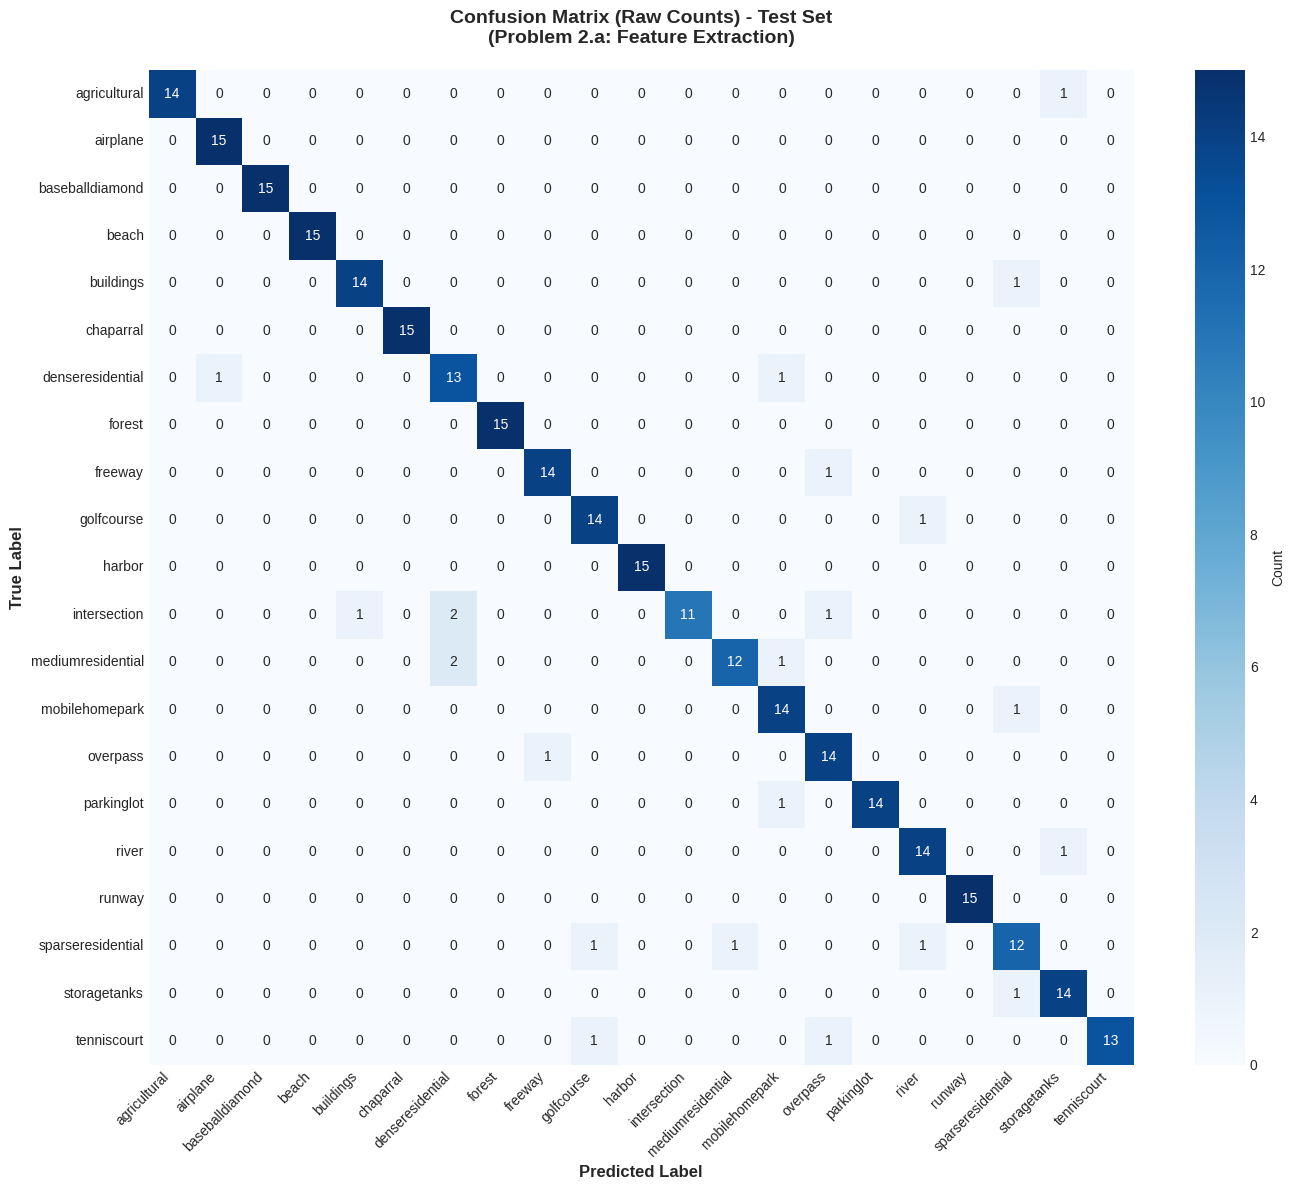

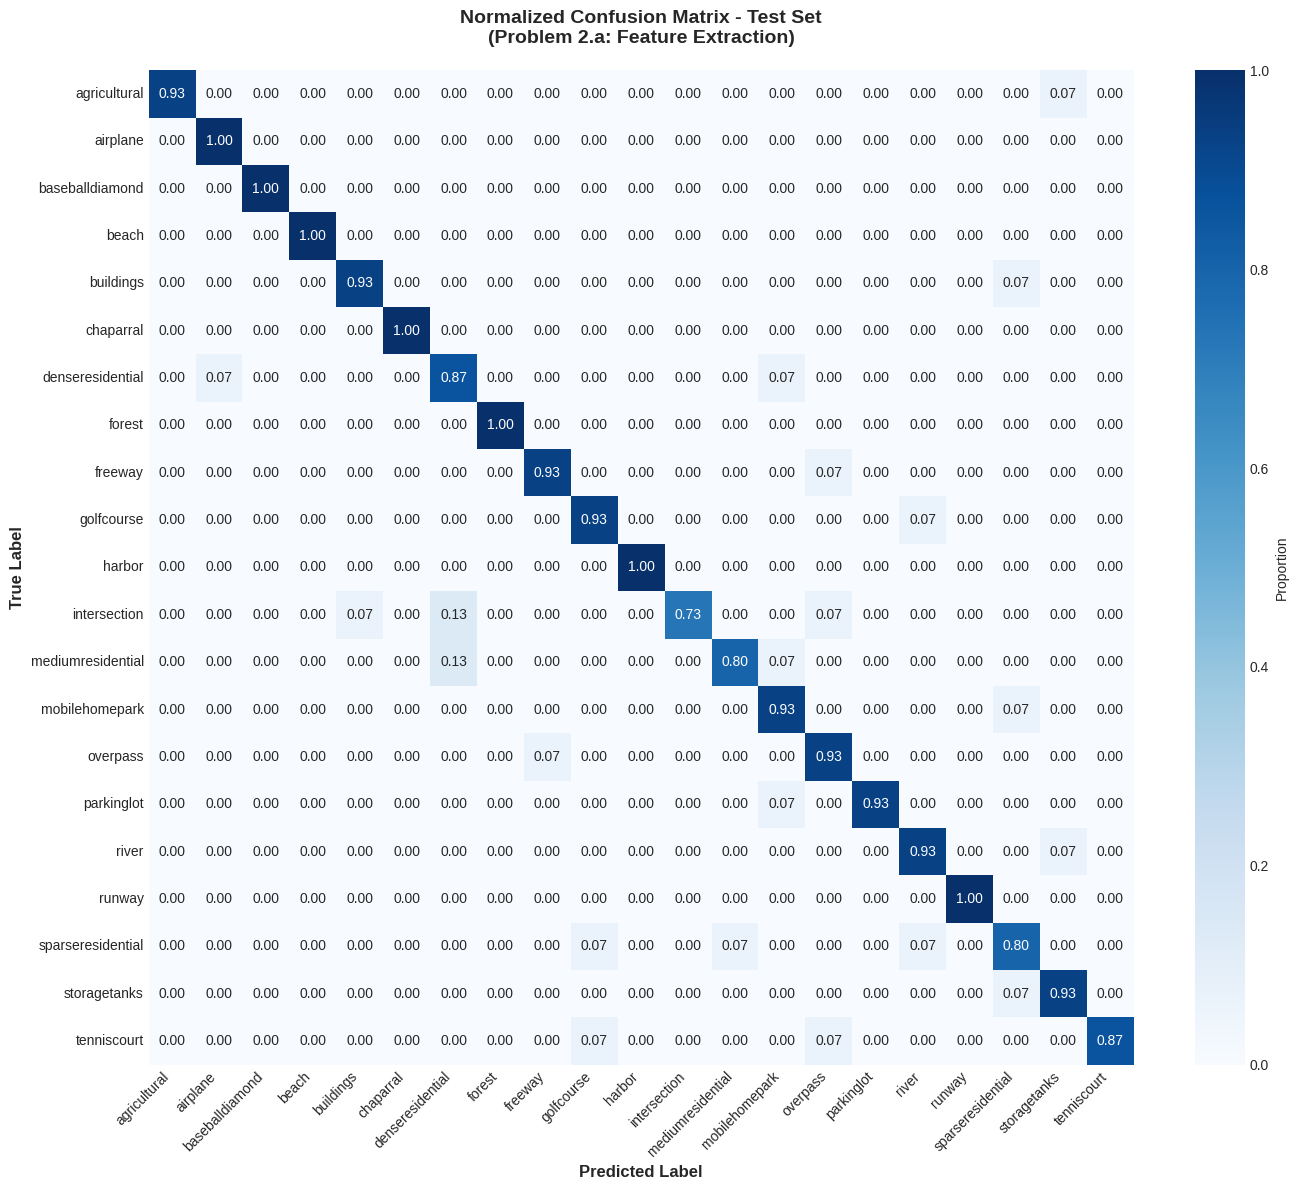


Confusion Matrix Statistics:
  Total samples: 315
  Correct predictions: 292
  Overall accuracy: 0.9270


In [15]:
# Confusion Matrix for Test Set (Raw Counts)
cm = confusion_matrix(labels_test, y_test_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Raw Counts) - Test Set\n(Problem 2.a: Feature Extraction)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Normalized Confusion Matrix (Required by assignment)
cm_normalized = confusion_matrix(labels_test, y_test_pred, normalize='true')

plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Proportion'}, vmin=0, vmax=1)
plt.title('Normalized Confusion Matrix - Test Set\n(Problem 2.a: Feature Extraction)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Statistics:")
print(f"  Total samples: {cm.sum()}")
print(f"  Correct predictions: {np.trace(cm)}")
print(f"  Overall accuracy: {np.trace(cm)/cm.sum():.4f}")


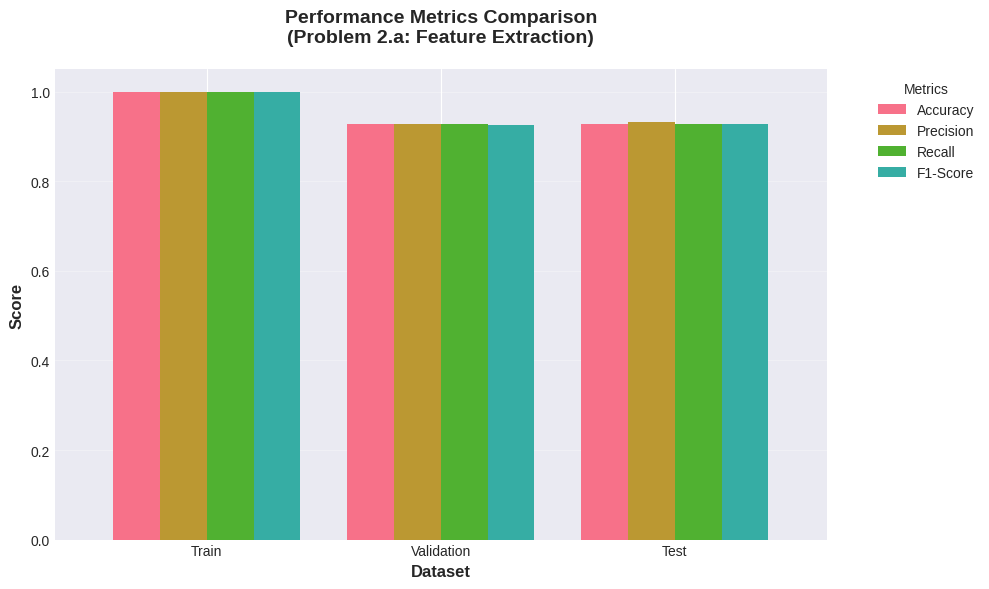


SUMMARY TABLE
           Train  Validation    Test
Accuracy     1.0      0.9270  0.9270
Precision    1.0      0.9285  0.9316
Recall       1.0      0.9270  0.9270
F1-Score     1.0      0.9263  0.9271


In [16]:
# Metrics Comparison Across Sets
metrics_df = pd.DataFrame({
    'Train': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score'])

fig, ax = plt.subplots(figsize=(10, 6))
metrics_df.T.plot(kind='bar', ax=ax, width=0.8)
plt.title('Performance Metrics Comparison\n(Problem 2.a: Feature Extraction)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xlabel('Dataset', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.ylim([0, 1.05])
plt.legend(title='Metrics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print metrics table
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(metrics_df.round(4))
print("="*60)


In [17]:
# Per-Class Performance (Test Set)
print("\nDetailed Classification Report (Test Set):")
print("="*80)
print(classification_report(labels_test, y_test_pred,
                          target_names=class_names,
                          digits=4))
print("="*80)



Detailed Classification Report (Test Set):
                   precision    recall  f1-score   support

     agricultural     1.0000    0.9333    0.9655        15
         airplane     0.9375    1.0000    0.9677        15
  baseballdiamond     1.0000    1.0000    1.0000        15
            beach     1.0000    1.0000    1.0000        15
        buildings     0.9333    0.9333    0.9333        15
        chaparral     1.0000    1.0000    1.0000        15
 denseresidential     0.7647    0.8667    0.8125        15
           forest     1.0000    1.0000    1.0000        15
          freeway     0.9333    0.9333    0.9333        15
       golfcourse     0.8750    0.9333    0.9032        15
           harbor     1.0000    1.0000    1.0000        15
     intersection     1.0000    0.7333    0.8462        15
mediumresidential     0.9231    0.8000    0.8571        15
   mobilehomepark     0.8235    0.9333    0.8750        15
         overpass     0.8235    0.9333    0.8750        15
       park

## 14. Per-Class Performance Visualization

Visualize precision, recall, and F1-score for each class.


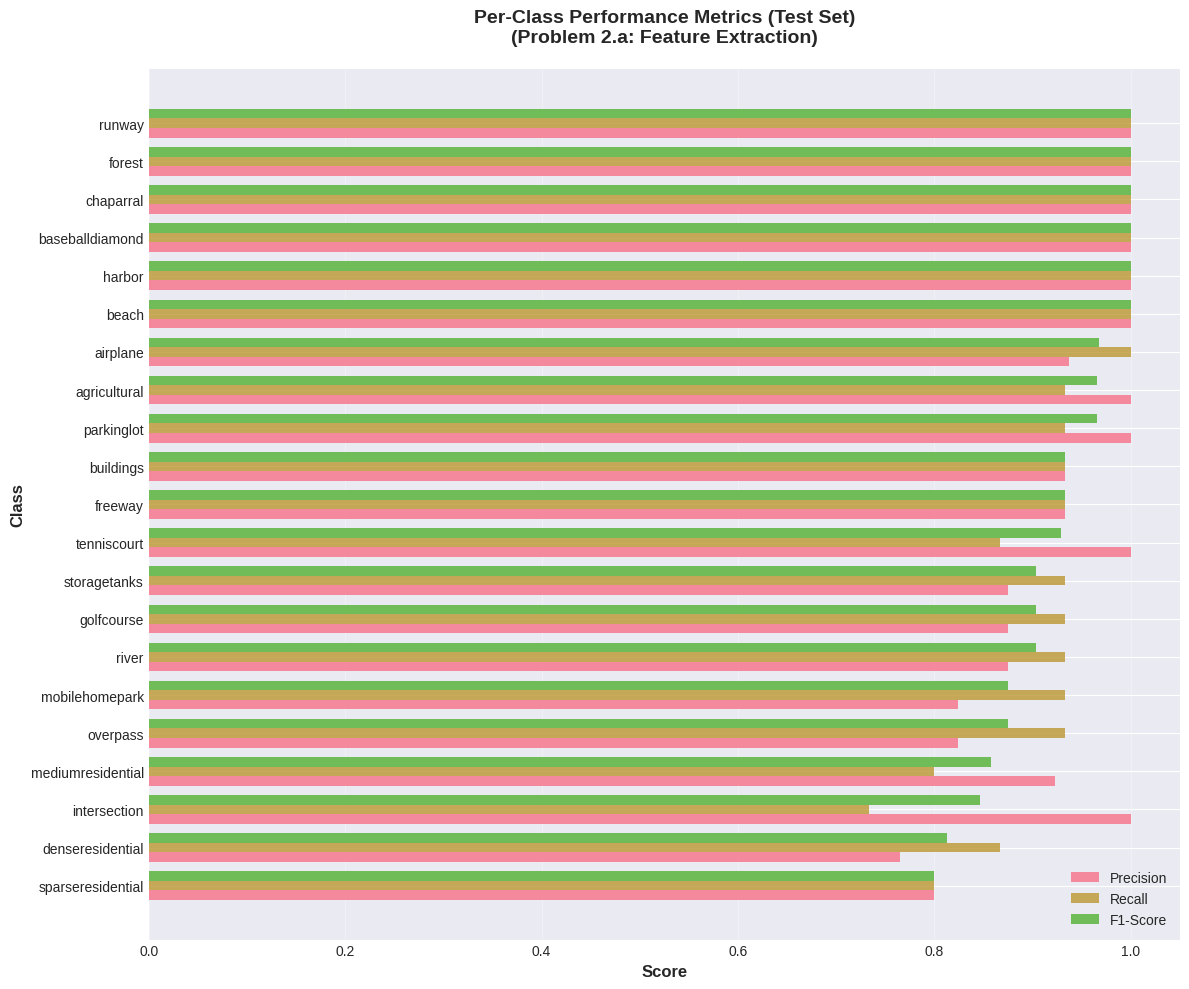


Per-Class Performance Summary:
            Class  Precision   Recall  F1-Score  Support
            beach   1.000000 1.000000  1.000000       15
           forest   1.000000 1.000000  1.000000       15
           runway   1.000000 1.000000  1.000000       15
        chaparral   1.000000 1.000000  1.000000       15
  baseballdiamond   1.000000 1.000000  1.000000       15
           harbor   1.000000 1.000000  1.000000       15
         airplane   0.937500 1.000000  0.967742       15
     agricultural   1.000000 0.933333  0.965517       15
       parkinglot   1.000000 0.933333  0.965517       15
        buildings   0.933333 0.933333  0.933333       15
          freeway   0.933333 0.933333  0.933333       15
      tenniscourt   1.000000 0.866667  0.928571       15
     storagetanks   0.875000 0.933333  0.903226       15
       golfcourse   0.875000 0.933333  0.903226       15
            river   0.875000 0.933333  0.903226       15
         overpass   0.823529 0.933333  0.875000       15

In [18]:
# Calculate per-class metrics
precision_per_class, recall_per_class, f1_per_class, support = precision_recall_fscore_support(
    labels_test, y_test_pred, average=None, zero_division=0
)

# Create DataFrame for visualization
per_class_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Support': support
})

# Sort by F1-score
per_class_df = per_class_df.sort_values('F1-Score', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
x = np.arange(len(per_class_df))
width = 0.25

bars1 = ax.barh(x - width, per_class_df['Precision'], width, label='Precision', alpha=0.8)
bars2 = ax.barh(x, per_class_df['Recall'], width, label='Recall', alpha=0.8)
bars3 = ax.barh(x + width, per_class_df['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Class', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics (Test Set)\n(Problem 2.a: Feature Extraction)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_yticks(x)
ax.set_yticklabels(per_class_df['Class'])
ax.legend()
ax.set_xlim([0, 1.05])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPer-Class Performance Summary:")
print(per_class_df.sort_values('F1-Score', ascending=False).to_string(index=False))


## 15. Save Model and Features

Save the trained XGBoost model and extracted features for future use.


In [19]:
# Save XGBoost model
import pickle

model_save_path = 'problem2a_xgboost_model.pkl'
with open(model_save_path, 'wb') as f:
    pickle.dump(xgb_classifier, f)
print(f"XGBoost model saved to: {model_save_path}")

# Optionally save extracted features
features_save_path = 'problem2a_features.npz'
np.savez(features_save_path,
         features_train=features_train,
         features_val=features_val,
         features_test=features_test,
         labels_train=labels_train,
         labels_val=labels_val,
         labels_test=labels_test,
         class_names=class_names)
print(f"Features saved to: {features_save_path}")


XGBoost model saved to: problem2a_xgboost_model.pkl
Features saved to: problem2a_features.npz


## 16. Conclusion and Analysis

### What I Did

For this problem, I used a two-step approach to classify the UCMerced land use images. First, I took a pretrained ResNet50 model (which was originally trained on ImageNet with millions of images) and used it as a feature extractor. Basically, I removed the last classification layer and just used the model to convert each 224x224 image into a 2048-dimensional feature vector. Then, instead of training another neural network, I fed these features into an XGBoost classifier to actually do the classification.

### Results and What They Mean

The model achieved 92.7% accuracy on the test set, which honestly surprised me in a good way. I wasn't expecting such high performance from just using frozen features without any fine-tuning. The training set accuracy was 100%, and validation was also around 92.7%, which suggests the model generalized well without overfitting too much.

Looking at the confusion matrix, I noticed some interesting patterns. Classes like beach, forest, runway, harbor, chaparral, and baseball diamond got perfect scores - every single test image was classified correctly. This makes sense because these classes have very distinct visual characteristics. A beach looks nothing like a forest, and a runway has those very recognizable white stripes.

The model struggled a bit more with the residential categories. Dense residential got confused with airplane and medium residential a few times (about 13% error rate). Medium residential sometimes got misclassified as dense residential. Intersection was the trickiest, getting mixed up with buildings and residential areas about 27% of the time. When you think about it, this confusion is pretty reasonable - urban and suburban areas from above can look quite similar, especially when you're dealing with roads, buildings, and houses all mixed together.

### Why This Approach Worked (and Its Limitations)

The main advantage here was speed. Since I didn't have to train the deep neural network part, the whole process took only about 13 minutes on a GPU. The ResNet features that were learned on ImageNet turned out to be general enough to work well on aerial images, even though ImageNet mostly has ground-level photos of objects and animals.

Using XGBoost instead of a neural network classifier also has some benefits - it's easier to understand what's going on, and it's less likely to overfit on a relatively small dataset like this one (2,100 images isn't huge by deep learning standards).

However, there are clear limitations. The ResNet features are frozen, meaning they can't adapt specifically to aerial imagery patterns. The model has to work with whatever features ImageNet training provided, which might not be optimal for distinguishing between, say, different types of residential areas. That's probably why those urban categories had more confusion.

### Comparing with What's Coming Next

This feature extraction method gives me a solid baseline to compare against. In Problem 2.b, I'll unfreeze just the classification head and train it specifically for this dataset. In Problem 2.c, I'll fine-tune the entire ResNet, which should theoretically give the best results but will take much longer to train. It'll be interesting to see if that extra training time translates into meaningfully better accuracy, or if 92.7% is already close to the ceiling for this dataset.

### Technical Details Worth Noting

A few implementation details that mattered:
- Had to use ImageNet normalization (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) for the images to match what ResNet was trained on
- Made sure the data split was stratified so each class had exactly 70-15-15 distribution
- Set random seed to 42 for reproducibility
- Used 200 estimators for XGBoost, which seemed to be enough based on the validation loss curve

Overall, this was a successful first attempt at the problem. Getting over 90% accuracy with relatively little training time is a good sign that transfer learning from ImageNet works well even for this different domain of aerial